### Loading the Dataset

In this step, we loaded the cleaned Shaguf dataset that was prepared in the previous phase.  
This dataset contains cleaned course information such as price, duration, discount rate, number of students, and instructor-related features.  
The goal of this notebook is to build a Decision Tree Regression model to predict student enrollment.

In [62]:
import pandas as pd
import numpy as np

df = pd.read_csv("shaguf_cleaned_final (1).csv")



### Previewing the Data

After loading the dataset, we displayed the first few rows to make sure the file was loaded correctly and to check the structure of the data.  
This also helped us see the available columns before choosing the features for the model.

In [63]:
df.head()

,url,title,content_type_Test Preparation,course_code_normalized,price_clean_normalized,old_price_clean_normalized,students_capped_normalized,duration_clean_normalized,discount_rate_actual_normalized,has_discount_clean,...,is_exam_prep,level_missing,instructor_popularity_Emerging,instructor_popularity_Established,instructor_popularity_Popular,instructor_course_count,instructor_avg_students,discount_rate_actual,students_capped,price_clean
0,https://shaguf.com/subject/1072,الفيزياء العامة,False,فيز 1103,0.841683,0.010500,0.828700,0.239316,0.0000,True,...,False,True,False,True,False,1,1103.000000,0.00,1103,2520.0
1,https://shaguf.com/subject/25,KSU - مبادئ الإدارة والأعمال,False,ادا 101,0.010354,0.010375,0.075883,0.264957,0.6265,True,...,False,False,True,False,False,2,101.000000,62.65,101,31.0
2,https://shaguf.com/subject/348,عال 111,False,عال 111,0.014028,0.012459,0.083396,0.358974,0.5786,True,...,False,True,True,False,False,6,89.333333,57.86,111,42.0
3,https://shaguf.com/subject/192,الاحصاء الاداري,False,كمي 207,0.003340,0.010375,0.000000,0.085470,0.8795,True,...,False,False,True,False,False,4,0.000000,87.95,0,10.0
4,https://shaguf.com/subject/630,عال 113,False,عال 113,0.014362,0.012459,0.084899,0.367521,0.5686,True,...,False,True,True,False,False,6,89.333333,56.86,113,43.0


### Creating a Copy of the Dataset

We created a copy of the dataset before applying any modelling changes.  
This is done to keep the original dataframe unchanged and avoid modifying the main dataset by mistake.

In [64]:
df_model = df.copy()

target_col = "students_capped"

print("Target column:", target_col)

Target column: students_capped


In [65]:
df_model["students_log"] = np.log1p(df_model[target_col])

if "price_log" not in df_model.columns:
    if "price_clean" in df_model.columns:
        df_model["price_log"] = np.log1p(df_model["price_clean"])
    elif "price" in df_model.columns:
        df_model["price_log"] = np.log1p(df_model["price"])

if "has_discount" not in df_model.columns:
    if "discount_rate_actual" in df_model.columns:
        df_model["has_discount"] = df_model["discount_rate_actual"] > 0
    elif "discount_percent" in df_model.columns:
        df_model["has_discount"] = df_model["discount_percent"] > 0

df_model.head()

,url,title,content_type_Test Preparation,course_code_normalized,price_clean_normalized,old_price_clean_normalized,students_capped_normalized,duration_clean_normalized,discount_rate_actual_normalized,has_discount_clean,...,instructor_popularity_Established,instructor_popularity_Popular,instructor_course_count,instructor_avg_students,discount_rate_actual,students_capped,price_clean,students_log,price_log,has_discount
0,https://shaguf.com/subject/1072,الفيزياء العامة,False,فيز 1103,0.841683,0.010500,0.828700,0.239316,0.0000,True,...,True,False,1,1103.000000,0.00,1103,2520.0,7.006695,7.832411,False
1,https://shaguf.com/subject/25,KSU - مبادئ الإدارة والأعمال,False,ادا 101,0.010354,0.010375,0.075883,0.264957,0.6265,True,...,False,False,2,101.000000,62.65,101,31.0,4.624973,3.465736,True
2,https://shaguf.com/subject/348,عال 111,False,عال 111,0.014028,0.012459,0.083396,0.358974,0.5786,True,...,False,False,6,89.333333,57.86,111,42.0,4.718499,3.761200,True
3,https://shaguf.com/subject/192,الاحصاء الاداري,False,كمي 207,0.003340,0.010375,0.000000,0.085470,0.8795,True,...,False,False,4,0.000000,87.95,0,10.0,0.000000,2.397895,True
4,https://shaguf.com/subject/630,عال 113,False,عال 113,0.014362,0.012459,0.084899,0.367521,0.5686,True,...,False,False,6,89.333333,56.86,113,43.0,4.736198,3.784190,True


In [66]:
df_model.columns

Index(['url', 'title', 'content_type_Test Preparation',
       'course_code_normalized', 'price_clean_normalized',
       'old_price_clean_normalized', 'students_capped_normalized',
       'duration_clean_normalized', 'discount_rate_actual_normalized',
       'has_discount_clean', 'is_free', 'is_exam_prep', 'level_missing',
       'instructor_popularity_Emerging', 'instructor_popularity_Established',
       'instructor_popularity_Popular', 'instructor_course_count',
       'instructor_avg_students', 'discount_rate_actual', 'students_capped',
       'price_clean', 'students_log', 'price_log', 'has_discount'],
      dtype='object')

In [67]:
features = [
    "price_log",
    "duration_clean_normalized",
    "discount_rate_actual",
    "is_free",
    "instructor_popularity_Emerging",
    "instructor_popularity_Established",
    "instructor_popularity_Popular",
    "instructor_course_count",
    "instructor_avg_students"
]

# keep only columns that actually exist in the dataset
features = [col for col in features if col in df_model.columns]



### Final Selected Features

The selected features were used as input variables for the model.  
The target variable was `students_log`, which represents the log-transformed number of students.  
Using these features allows the model to learn patterns between course characteristics and student enrollment.

In [68]:
print("Selected features:", features)

X = df_model[features]
y = df_model["students_log"]

Selected features: ['price_log', 'duration_clean_normalized', 'discount_rate_actual', 'is_free', 'instructor_popularity_Emerging', 'instructor_popularity_Established', 'instructor_popularity_Popular', 'instructor_course_count', 'instructor_avg_students']


### Splitting the Data

We split the dataset into training and testing sets.  
The training set was used to train the Decision Tree model, while the testing set was used to evaluate how well the model performs on unseen data.  
We used 80% of the data for training and 20% for testing.

In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

### Building the Decision Tree Regressor

In this step, we built a Decision Tree Regressor model.  
Decision Tree was chosen because it can capture non-linear relationships between the features and student enrollment.  
We used `max_depth = 5` to control the complexity of the tree and reduce overfitting.

In [70]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

### Evaluating the Model

After training the model, we used the test set to make predictions.  
Then, we evaluated the model using MAE, RMSE, and R².

MAE shows the average prediction error.  
RMSE gives more weight to larger errors.  
R² shows how much of the variation in student enrollment is explained by the model.

In [71]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_dt = dt_model.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Regression Results:")
print("MAE:", round(mae_dt, 4))
print("RMSE:", round(rmse_dt, 4))
print("R²:", round(r2_dt, 4))

Decision Tree Regression Results:
MAE: 0.9301
RMSE: 1.6359
R²: 0.4654


### Decision Tree Results
The Decision Tree model achieved the following results:

- MAE = 0.9301
- RMSE = 1.6359
- R² = 0.4654

Since the target variable was log-transformed, MAE and RMSE are interpreted on the log scale.

The R² score means that the model explained about 46.5% of the variation in student enrollment. This is a clear improvement compared to the baseline model, which had a lower R² score. This result shows that Decision Tree was able to capture more complex patterns in the data than a simple linear model.

### Feature Importance

We calculated feature importance to understand which variables had the strongest effect on the model prediction.  
This helps explain how the Decision Tree made its decisions and which features were most useful for predicting student enrollment.

In [72]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": dt_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_df

,Feature,Importance
8,instructor_avg_students,0.860206
7,instructor_course_count,0.064483
0,price_log,0.027564
2,discount_rate_actual,0.026968
1,duration_clean_normalized,0.018097
5,instructor_popularity_Established,0.002683
3,is_free,0.000000
4,instructor_popularity_Emerging,0.000000
6,instructor_popularity_Popular,0.000000


### Feature Importance Interpretation

The most important feature was instructor_avg_students, which means that instructor-level enrollment history had the strongest effect on predicting course enrollment.

This supports our earlier EDA finding that instructor-related factors are strongly associated with course popularity.

Other features such as instructor course count, price, discount rate, and duration had smaller effects in this model.

However, this result should be interpreted carefully because instructor_avg_students is calculated from enrollment-related information, so it may strongly reflect the target variable.

### Visualizing Feature Importance

We used a bar chart to make the feature importance easier to understand.  
The chart shows which features contributed the most to the Decision Tree model.

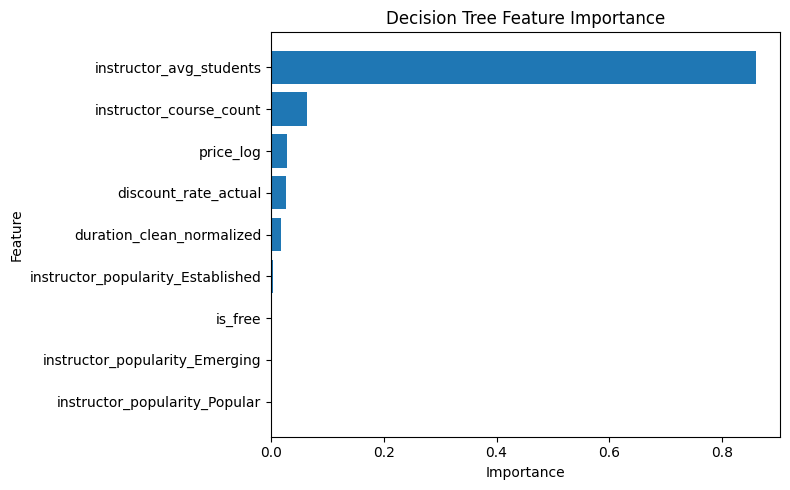

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Conclusion

In this notebook, we built a Decision Tree Regression model to predict student enrollment in Shaguf courses.

The model performed better than the baseline model and achieved an R² score of 0.4654. This means that the model explained about 46.5% of the variation in student enrollment.

The results showed that instructor-related features, especially instructor_avg_students, had the strongest effect on the model prediction. This suggests that instructor history is strongly related to course popularity in this dataset.

Overall, Decision Tree was useful because it captured non-linear relationships in the data. However, Random Forest still remains slightly better because it combines multiple trees and usually gives more stable predictions.